# Stock Price Prediction

In [1]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import statsmodels.api as sm
import plotly.express as px
import numpy as np

from datetime import date,timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM 

In [2]:
df=pd.read_csv('GOOG.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-05-20,1389.579956,1410.420044,1387.250000,1406.719971,1406.719971,1655400
1,2020-05-21,1408.000000,1415.489990,1393.449951,1402.800049,1402.800049,1385000
2,2020-05-22,1396.709961,1412.760010,1391.829956,1410.420044,1410.420044,1309400
3,2020-05-26,1437.270020,1441.000000,1412.130005,1417.020020,1417.020020,2060600
4,2020-05-27,1417.250000,1421.739990,1391.290039,1417.839966,1417.839966,1685800


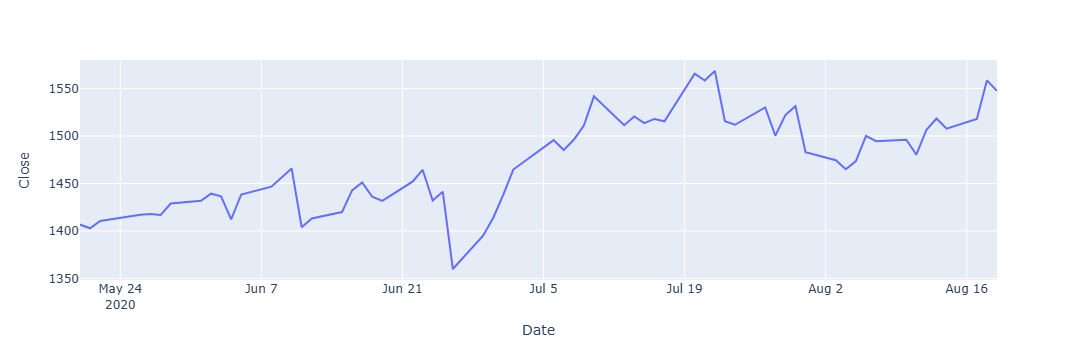

In [6]:
px.line(df, x='Date',y=df['Close'])

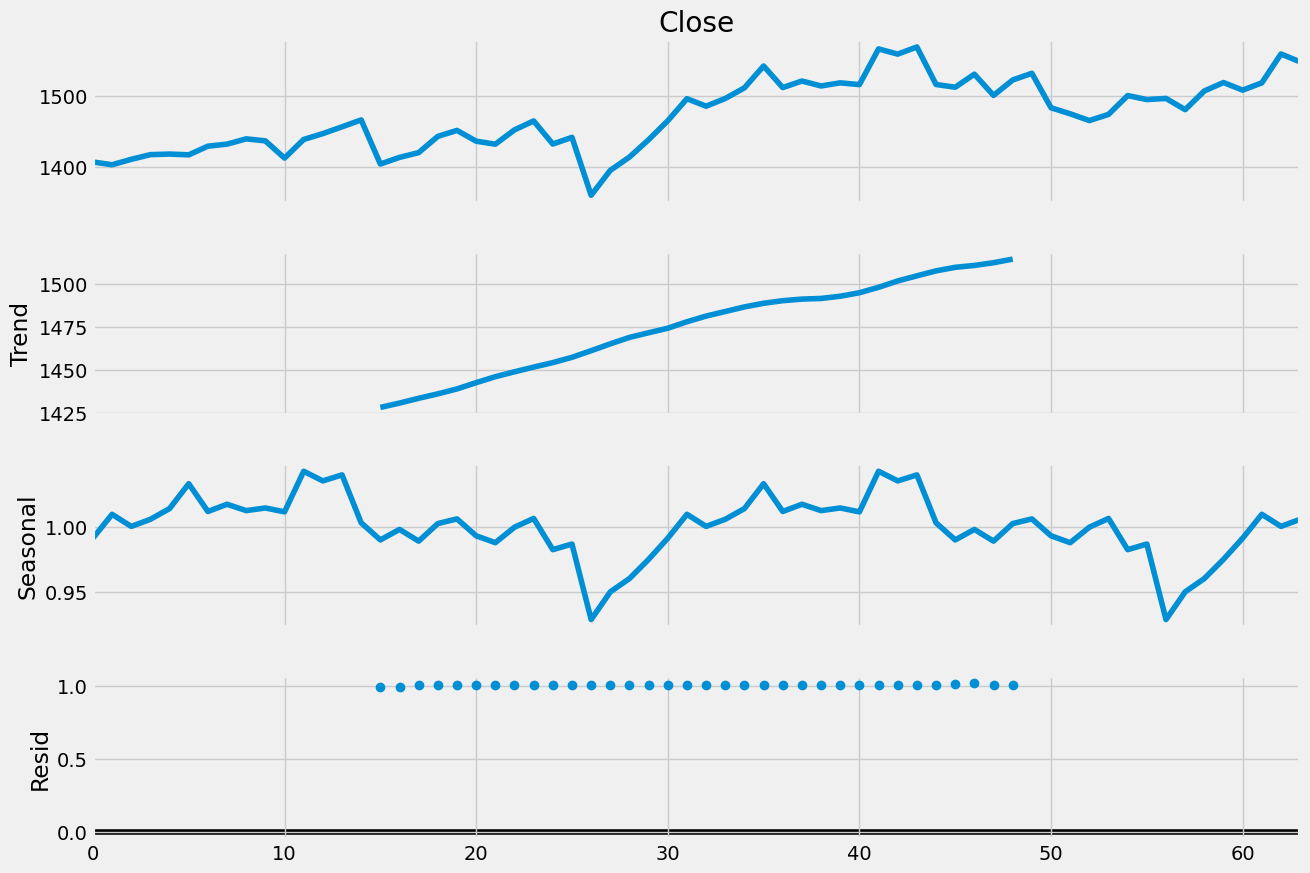

In [7]:
result=seasonal_decompose(df['Close'],model='multiplicative', period=30)
fig=result.plot()
fig.set_size_inches(15,10)

In [8]:
model=sm.tsa.statespace.SARIMAX(df['Close'])
results=model.fit()

C:\Users\MONSTER\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.



In [9]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                   64
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -297.190
Date:                Sun, 12 Apr 2026   AIC                            598.379
Time:                        14:13:22   BIC                            602.697
Sample:                             0   HQIC                           600.080
                                 - 64                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.002    546.367      0.000       0.996       1.003
sigma2       555.6426     79.994      6.946      0.000     398.857     712.429
===================================================================================
Ljung-Box (L1) (Q):                   2.29   Jarque-Bera (JB):                27.64
Prob(Q):                              0.13   Prob(JB):                         0.00
Heteroskedasticity (H):               1.54   Skew:                            -1.18
Prob(H) (two-sided):                  0.33   Kurtosis:                         5.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [10]:
predictions=results.predict(len(df),len(df)+7)

In [11]:
predictions

64    1547.331104
65    1547.132205
66    1546.933331
67    1546.734482
68    1546.535660
69    1546.336863
70    1546.138091
71    1545.939345
Name: predicted_mean, dtype: float64

<Axes: >

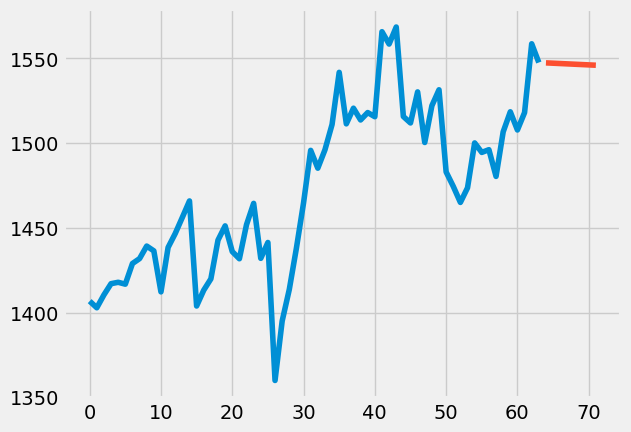

In [13]:
df['Close'].plot()
predictions.plot()

In [14]:
train_set=df.iloc[:,1:2].values

In [15]:
sc = MinMaxScaler()

In [16]:
train_set=sc.fit_transform(train_set)

In [18]:
x_train = train_set[:-1]
y_train = train_set[1:]

In [19]:
model=Sequential()
model.add(LSTM(units=4,activation='sigmoid', input_shape=(None,1)))
model.add(Dense(units=1))

C:\Users\MONSTER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [20]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [21]:
model.fit(x_train,y_train, batch_size=32, epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.2678
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2627 
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2577
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2529
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2480
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2433 
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2386
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2338 
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2292 
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2248 
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2202
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2159 
Epoch 13/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2117
Epoch 14/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2073
Epoch 15/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2033
Epoch 16/20
2/2 ━━━━━━━━━━━━

In [22]:
test=pd.read_csv('GOOG.csv')

In [23]:
test=test.iloc[:,1:2].values

In [24]:
test_set=sc.fit_transform(test)

In [25]:
tahmin=model.predict(test_set)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 


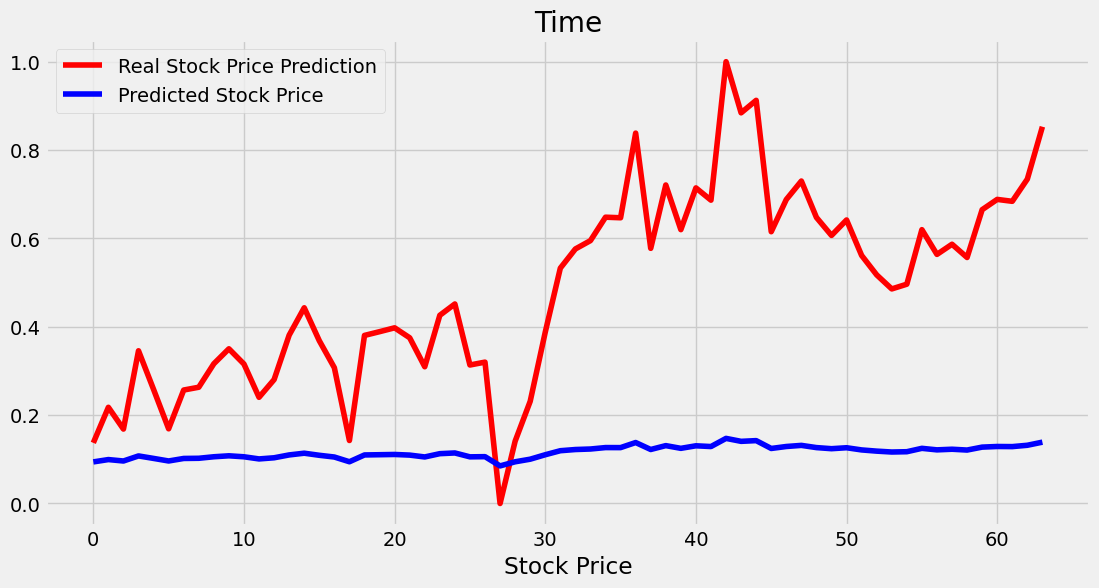

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(test_set, color='red', label='Real Stock Price Prediction')
plt.plot(tahmin, color='blue', label='Predicted Stock Price ')
plt.title('Time')
plt.xlabel('Stock Price')
plt.legend()
plt.show()